### ¿se puede clasificar si una empresa es “exitosa” según sus características?


Si, habría que definir que es exitosa, pero si es por ejemplo ventas por encima del promedio entonces podemos entrenar un modelo logístico que estime la probabilidad de éxito en función de variables

In [19]:
import pandas as pd
import numpy as np

In [20]:
df = pd.read_csv("wbes_sintetico.csv")

cols = [
    "sales_annual_usd",
    "labor_productivity_usd_per_employee",
    "employees",
    "firm_age_years",
    "training",
    "access_finance",
    "exporter",
    "competition_level",
    "digital_payments",
]

completeDf = df[cols]

df_model = completeDf.dropna()

In [21]:
global_mean_sales = df_model["sales_annual_usd"].mean()
df_model["successful"] = (df_model["sales_annual_usd"] > global_mean_sales).astype(int)

df_model["successful"].value_counts(dropna=False)

C:\Users\angel\AppData\Local\Temp\ipykernel_21464\1771778913.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model["successful"] = (df_model["sales_annual_usd"] > global_mean_sales).astype(int)


successful
0    630
1    416
Name: count, dtype: int64

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

features = ["employees", "training", "exporter", "access_finance", "competition_level"]
target = "successful"

X = df_model[features].copy()
y = df_model[target].astype(int)

for c in ["training", "exporter", "access_finance"]:
    if c in X.columns:
        X[c] = pd.to_numeric(X[c], errors="coerce")

# Separar train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X_train.columns if c not in num_cols]

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ],
    remainder="drop"
)

clf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=2000))
])

clf

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


#### Entrenar modelo

In [23]:
clf.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [24]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {acc:.4f}\n")
print("Matriz de confusión:\n", cm, "\n")
print(classification_report(y_test, y_pred, digits=4))

Accuracy: 0.7672

Matriz de confusión:
 [[141  17]
 [ 44  60]] 

              precision    recall  f1-score   support

           0     0.7622    0.8924    0.8222       158
           1     0.7792    0.5769    0.6630       104

    accuracy                         0.7672       262
   macro avg     0.7707    0.7347    0.7426       262
weighted avg     0.7689    0.7672    0.7590       262



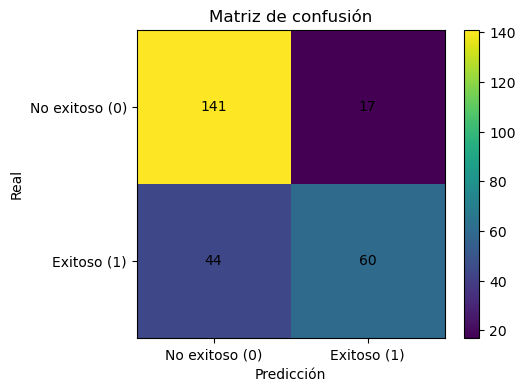

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))
plt.imshow(cm, interpolation="nearest")
plt.title("Matriz de confusión")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.xticks([0,1], ["No exitoso (0)", "Exitoso (1)"])
plt.yticks([0,1], ["No exitoso (0)", "Exitoso (1)"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.show()

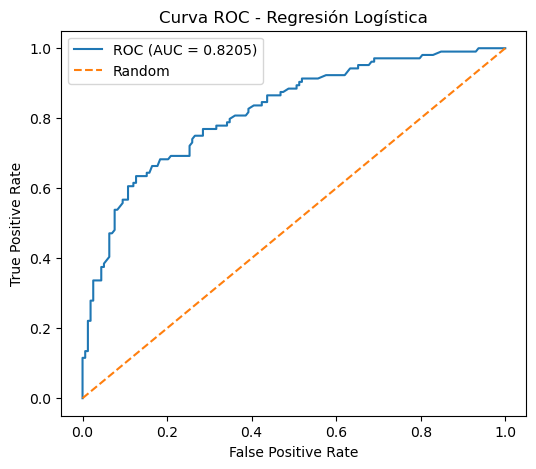

0.8204722492697175

In [26]:
from sklearn.metrics import roc_curve, auc

y_proba = clf.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"ROC (AUC = {roc_auc:.4f})")
plt.plot([0,1], [0,1], linestyle="--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Regresión Logística")
plt.legend()
plt.show()

roc_auc

#### Interpretacion

El modelo tiene una precisión del 77%, por lo que clasifica correctamente la mayoría de las empresas. La matriz de confusión muestra que identifica mejor a las no exitosas que a las exitosas.

El AUC de 0.82 indica que el modelo distingue bien entre éxito y fracaso. En general, factores como más empleados, financiamiento, capacitación y exportación aumentan la probabilidad de éxito empresarial.